# Funciones de transferencia, convolución y compensadores clásicos

## Una introducción progresiva al análisis y diseño de sistemas dinámicos lineales

**Tema central:**  
Cómo la transformada de Laplace permite convertir la dinámica temporal de los sistemas en álgebra de bloques, y cómo esa estructura habilita el diseño de compensadores de adelanto, atraso y adelanto-atraso.

---

## Propósito del notebook

Este notebook está pensado como un pequeño libro técnico-pedagógico.  
El objetivo no es solamente “hacer cuentas”, sino comprender por qué funcionan las herramientas clásicas de control:

- función de transferencia,
- convolución,
- álgebra de bloques,
- polos y ceros,
- respuesta temporal,
- respuesta en frecuencia,
- compensadores,
- teoremas de valor inicial, final y medio.

Se trabajará con teoría, fórmulas, ejemplos numéricos, simulaciones y gráficas en Python.

# Índice

1. Prólogo  
2. Presentación conceptual del problema  
3. Sistemas LTI: linealidad e invariancia temporal  
4. Convolución: la memoria matemática del sistema  
5. Transformada de Laplace y función de transferencia  
6. Álgebra de bloques y su fundamento matemático  
7. Polos, ceros y comportamiento físico  
8. Respuesta temporal: escalón, impulso y transitorio  
9. Respuesta en frecuencia: Bode, fase y ganancia  
10. Compensadores clásicos  
    - Adelanto  
    - Atraso  
    - Adelanto-atraso  
11. Diseño práctico sobre una planta de ejemplo  
12. Teoremas de valor inicial, final y medio  
13. Comparación gráfica de sistemas compensados  
14. Conclusiones generales  
15. Ejercicios propuestos

# 1. Prólogo

En control automático, una de las ideas más importantes es que un sistema físico puede ser representado por una relación entre entrada y salida.

Si la entrada es $x(t)$ y la salida es $y(t)$, la pregunta fundamental es:

$$
\text{¿Qué hace el sistema con la señal que recibe?}
$$

En el dominio temporal, esa pregunta suele conducir a ecuaciones diferenciales.  
En el dominio de Laplace, esas ecuaciones se transforman en expresiones algebraicas.

La función de transferencia aparece como:

$$
G(s)=\frac{Y(s)}{X(s)}
$$

Pero esa expresión no debe leerse solo como un cociente.  
Debe interpretarse como la representación algebraica de un operador dinámico.

La idea profunda es:

$$
Y(s)=G(s)X(s)
$$

que en el tiempo equivale a:

$$
y(t)=g(t)*x(t)
$$

donde $*$ representa convolución.

La multiplicación de bloques en Laplace es, en realidad, convolución de dinámicas en el tiempo.

# 2. Presentación conceptual del problema

Supongamos un sistema físico cualquiera:

$$
x(t) \longrightarrow \boxed{\text{Sistema}} \longrightarrow y(t)
$$

Ejemplos:

| Entrada | Sistema | Salida |
|---|---|---|
| tensión aplicada | circuito RC | tensión en capacitor |
| torque | motor | velocidad angular |
| caudal de calor | sistema térmico | temperatura |
| fuerza | masa-resorte-amortiguador | posición |
| señal de referencia | servomecanismo | posición real |

La función de transferencia representa la dinámica propia del sistema:

$$
G(s)=\frac{Y(s)}{X(s)}
$$

bajo condiciones iniciales nulas.

Esto último es muy importante: la función de transferencia describe la relación entrada-salida propia del sistema, sin energía inicial almacenada.

# 3. Sistemas LTI: linealidad e invariancia temporal

La teoría clásica de función de transferencia se apoya especialmente en sistemas **LTI**:

$$
\text{LTI} = \text{Linear Time-Invariant}
$$

Es decir:

## Linealidad

Si:

$$
x_1(t) \rightarrow y_1(t)
$$

y:

$$
x_2(t) \rightarrow y_2(t)
$$

entonces:

$$
a x_1(t)+b x_2(t) \rightarrow a y_1(t)+b y_2(t)
$$

Esto permite superposición.

## Invariancia temporal

Si:

$$
x(t) \rightarrow y(t)
$$

entonces:

$$
x(t-t_0) \rightarrow y(t-t_0)
$$

Esto significa que el sistema no cambia sus propiedades con el tiempo.

## Consecuencia fundamental

Todo sistema LTI puede representarse mediante convolución con su respuesta impulsional:

$$
y(t)=g(t)*x(t)
$$

donde $g(t)$ es la respuesta al impulso.

# 4. Convolución: la memoria matemática del sistema

La convolución continua se define como:

$$
y(t)=\int_0^t g(\tau)x(t-\tau)d\tau
$$

Esta integral dice algo físicamente muy profundo:

> La salida actual depende de toda la historia pasada de la entrada, ponderada por la memoria dinámica del sistema.

El término $g(\tau)$ indica cuánto pesa un evento pasado en la salida actual.

Por eso la convolución aparece naturalmente en sistemas con memoria:

- capacitores,
- inductores,
- masas,
- resortes,
- sistemas térmicos,
- procesos químicos,
- sistemas mecánicos,
- motores eléctricos.

Un sistema sin memoria podría responder instantáneamente:

$$
y(t)=Kx(t)
$$

Pero un sistema dinámico real generalmente responde como:

$$
y(t)=g(t)*x(t)
$$

In [2]:
# Configuración inicial
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.integrate import cumulative_trapezoid

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

## Ejemplo práctico: convolución de una entrada escalón con una respuesta impulsional

Tomemos un sistema de primer orden:

$$
G(s)=\frac{1}{s+1}
$$

Su respuesta impulsional es:

$$
g(t)=e^{-t}u(t)
$$

Si la entrada es un escalón unitario:

$$
x(t)=u(t)
$$

entonces la salida será:

$$
y(t)=g(t)*x(t)
$$

Analíticamente:

$$
y(t)=1-e^{-t}
$$

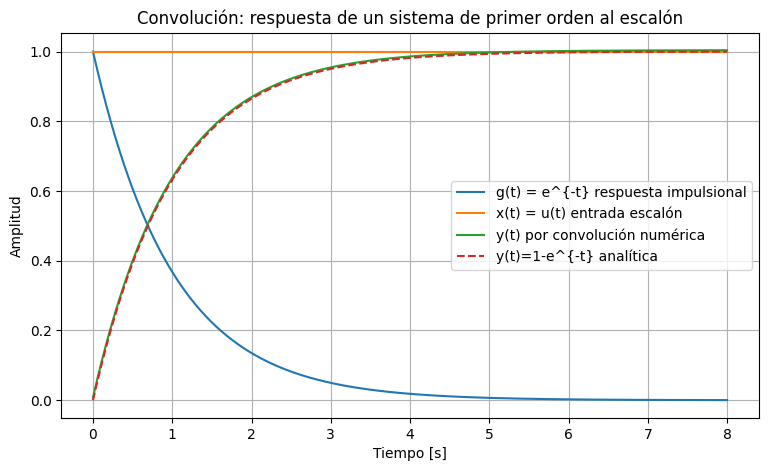

In [3]:
t = np.linspace(0, 8, 1000)
dt = t[1] - t[0]

g = np.exp(-t)       # respuesta impulsional
x = np.ones_like(t)  # escalón unitario

# Convolución numérica
y_conv = np.convolve(g, x)[:len(t)] * dt

# Solución analítica
y_exacta = 1 - np.exp(-t)

plt.figure()
plt.plot(t, g, label="g(t) = e^{-t} respuesta impulsional")
plt.plot(t, x, label="x(t) = u(t) entrada escalón")
plt.plot(t, y_conv, label="y(t) por convolución numérica")
plt.plot(t, y_exacta, "--", label="y(t)=1-e^{-t} analítica")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Convolución: respuesta de un sistema de primer orden al escalón")
plt.legend()
plt.show()

# 5. Laplace y función de transferencia

La transformada de Laplace tiene una propiedad central:

$$
\mathcal{L}\{g(t)*x(t)\}=G(s)X(s)
$$

Esto convierte una integral de convolución en una multiplicación algebraica.

Por eso, si:

$$
y(t)=g(t)*x(t)
$$

entonces:

$$
Y(s)=G(s)X(s)
$$

y:

$$
G(s)=\frac{Y(s)}{X(s)}
$$

Esta es la base real del álgebra de bloques.

# 6. Álgebra de bloques y su fundamento matemático

Supongamos dos sistemas en cascada:

$$
x(t) \rightarrow g_1(t) \rightarrow z(t) \rightarrow g_2(t) \rightarrow y(t)
$$

En el tiempo:

$$
z(t)=g_1(t)*x(t)
$$

$$
y(t)=g_2(t)*z(t)
$$

Reemplazando:

$$
y(t)=g_2(t)*g_1(t)*x(t)
$$

Por asociatividad de la convolución:

$$
y(t)=(g_2*g_1)*x(t)
$$

En Laplace:

$$
Y(s)=G_2(s)G_1(s)X(s)
$$

Entonces:

$$
G_{eq}(s)=G_2(s)G_1(s)
$$

La multiplicación de bloques es la imagen algebraica de convoluciones sucesivas.

# 7. Polos, ceros y comportamiento físico

Una función de transferencia racional tiene la forma:

$$
G(s)=K\frac{(s-z_1)(s-z_2)\cdots(s-z_m)}
{(s-p_1)(s-p_2)\cdots(s-p_n)}
$$

Los valores $z_i$ son ceros.  
Los valores $p_i$ son polos.

## Polos

Los polos determinan los modos naturales del sistema:

- estabilidad,
- velocidad,
- oscilación,
- amortiguamiento,
- tiempo de establecimiento.

## Ceros

Los ceros modifican la forma de la respuesta:

- pendiente inicial,
- sobrepico,
- cancelaciones dinámicas,
- comportamiento transitorio.

En control, diseñar compensadores significa agregar polos y ceros de manera inteligente.

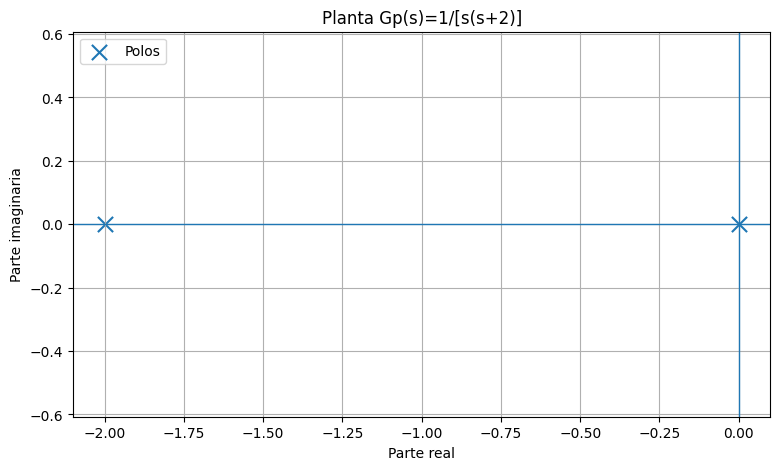

In [4]:
def plot_pz(num, den, title="Mapa de polos y ceros"):
    z, p, k = signal.tf2zpk(num, den)
    plt.figure()
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    if len(z) > 0:
        plt.scatter(np.real(z), np.imag(z), marker='o', s=100, label="Ceros")
    if len(p) > 0:
        plt.scatter(np.real(p), np.imag(p), marker='x', s=120, label="Polos")
    plt.xlabel("Parte real")
    plt.ylabel("Parte imaginaria")
    plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.show()

# Planta ejemplo
num_p = [1]
den_p = [1, 2, 0]  # s(s+2)

plot_pz(num_p, den_p, "Planta Gp(s)=1/[s(s+2)]")

# 8. Respuesta temporal

Consideremos la planta:

$$
G_p(s)=\frac{1}{s(s+2)}
$$

Tiene un integrador y un polo real en $-2$.

Ahora vamos a observar su respuesta al escalón en lazo cerrado con realimentación unitaria y ganancia $K$:

$$
T(s)=\frac{KG_p(s)}{1+KG_p(s)}
$$

Si:

$$
G_p(s)=\frac{1}{s(s+2)}
$$

entonces:

$$
T(s)=\frac{K}{s^2+2s+K}
$$

Comparando con el segundo orden estándar:

$$
T(s)=\frac{\omega_n^2}{s^2+2\zeta\omega_n s+\omega_n^2}
$$

obtenemos:

$$
\omega_n=\sqrt{K}
$$

$$
2\zeta\omega_n=2
$$

$$
\zeta=\frac{1}{\sqrt{K}}
$$

Esto muestra una idea central:

> al aumentar $K$, aumenta la rapidez, pero disminuye el amortiguamiento.

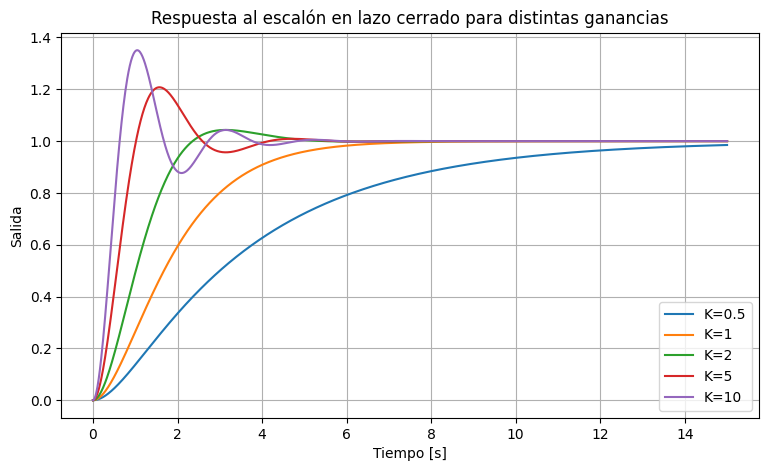

In [5]:
def closed_loop_tf(num, den):
    # Realimentación unitaria: T = G/(1+G)
    # G = num/den -> T = num/(den+num) igualando longitudes
    n = np.array(num, dtype=float)
    d = np.array(den, dtype=float)
    if len(n) < len(d):
        n_pad = np.pad(n, (len(d)-len(n), 0))
        d_pad = d
    else:
        d_pad = np.pad(d, (len(n)-len(d), 0))
        n_pad = n
    den_cl = d_pad + n_pad
    return n, den_cl

t = np.linspace(0, 15, 1000)

plt.figure()
for K in [0.5, 1, 2, 5, 10]:
    num_ol = [K]
    den_ol = [1, 2, 0]
    num_cl, den_cl = closed_loop_tf(num_ol, den_ol)
    sys_cl = signal.TransferFunction(num_cl, den_cl)
    tout, y = signal.step(sys_cl, T=t)
    plt.plot(tout, y, label=f"K={K}")

plt.title("Respuesta al escalón en lazo cerrado para distintas ganancias")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.legend()
plt.show()

# 9. Respuesta en frecuencia

Para analizar cómo un sistema responde a senoidales de distinta frecuencia, usamos:

$$
G(j\omega)
$$

El módulo:

$$
|G(j\omega)|
$$

indica amplificación o atenuación.

La fase:

$$
\angle G(j\omega)
$$

indica desfase.

Esto es esencial porque los compensadores suelen diseñarse para modificar:

- margen de fase,
- margen de ganancia,
- ancho de banda,
- precisión en baja frecuencia,
- sensibilidad al ruido en alta frecuencia.

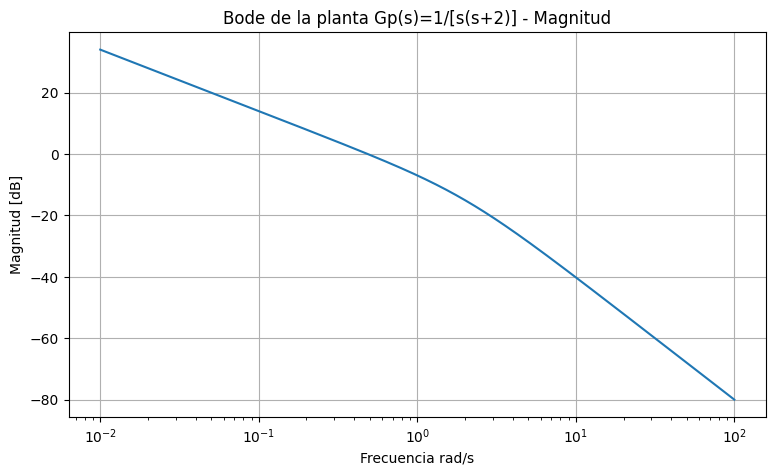

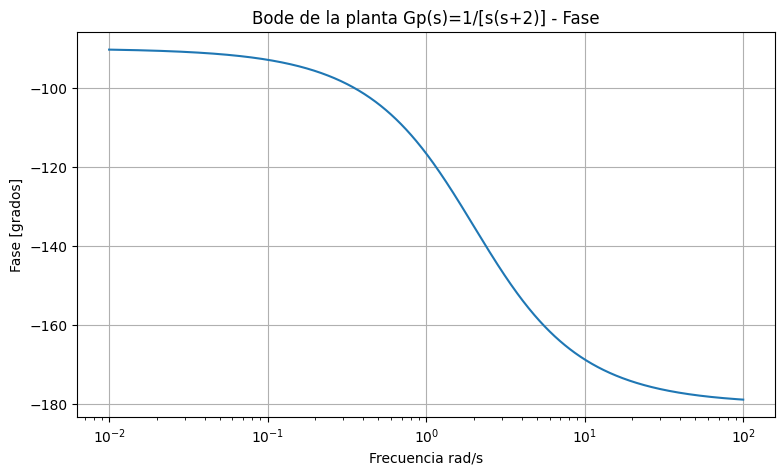

In [6]:
def bode_plot(num, den, title="Bode"):
    w, mag, phase = signal.bode((num, den), w=np.logspace(-2, 2, 1000))

    plt.figure()
    plt.semilogx(w, mag)
    plt.xlabel("Frecuencia rad/s")
    plt.ylabel("Magnitud [dB]")
    plt.title(title + " - Magnitud")
    plt.show()

    plt.figure()
    plt.semilogx(w, phase)
    plt.xlabel("Frecuencia rad/s")
    plt.ylabel("Fase [grados]")
    plt.title(title + " - Fase")
    plt.show()

bode_plot(num_p, den_p, "Bode de la planta Gp(s)=1/[s(s+2)]")

# 10. Compensadores clásicos

Un compensador es un sistema dinámico diseñado para modificar el comportamiento de la planta.

Se coloca generalmente en serie con la planta:

$$
G_{OL}(s)=G_c(s)G_p(s)
$$

Con realimentación unitaria:

$$
T(s)=\frac{G_c(s)G_p(s)}{1+G_c(s)G_p(s)}
$$

La ecuación característica es:

$$
1+G_c(s)G_p(s)=0
$$

Los polos del sistema cerrado dependen directamente del compensador.

Por eso, el compensador no “corrige la salida” solamente.  
Modifica la estructura dinámica del sistema.

## 10.1 Compensador de adelanto

Forma típica:

$$
G_c(s)=K_c\frac{s+z}{s+p}
$$

con:

$$
z<p
$$

En el plano $s$, esto significa:

$$
-z \quad \text{está más cerca del origen que} \quad -p
$$

Ejemplo:

$$
G_c(s)=\frac{s+5}{s+20}
$$

El compensador de adelanto agrega fase positiva en una banda de frecuencia.

Efectos típicos:

- aumenta margen de fase,
- mejora estabilidad relativa,
- acelera la respuesta,
- aumenta ancho de banda,
- puede amplificar ruido de alta frecuencia.

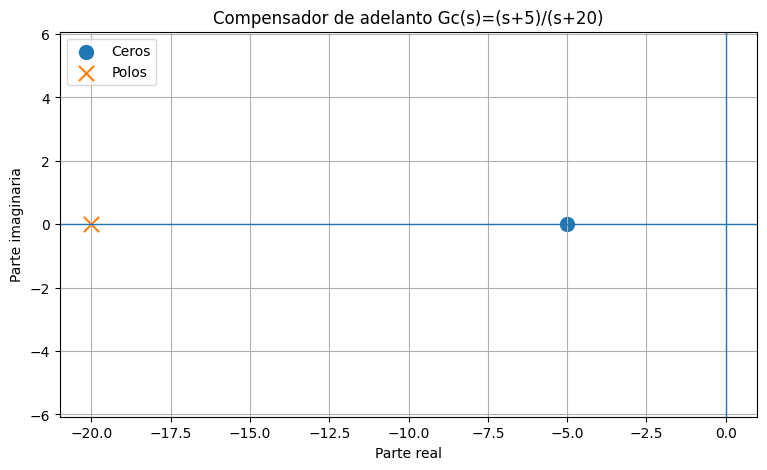

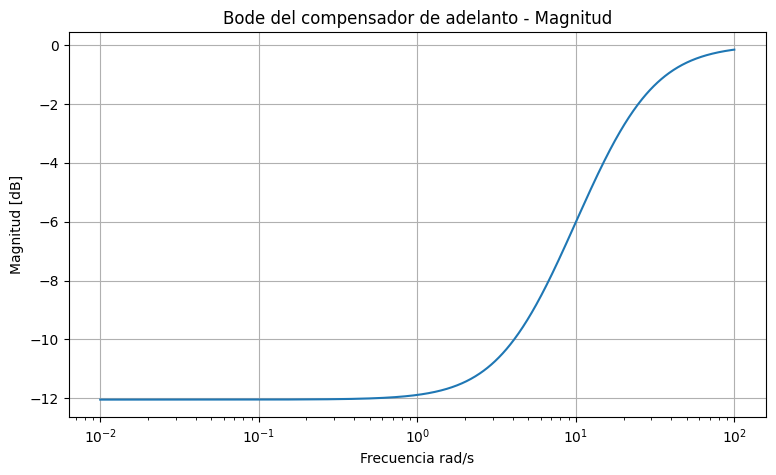

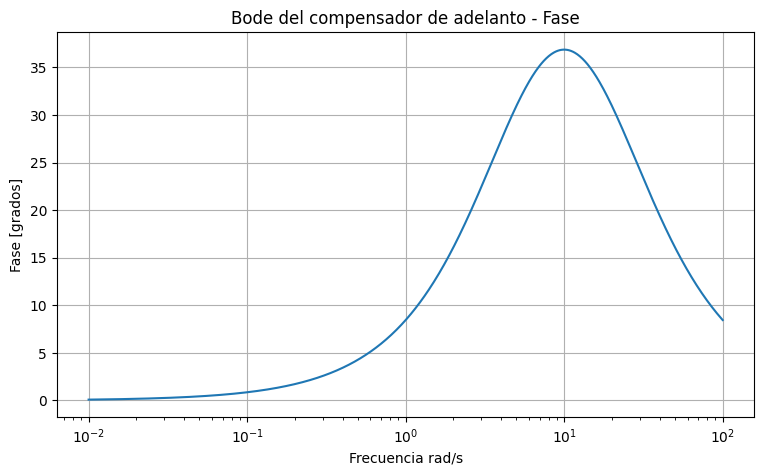

In [7]:
# Compensador de adelanto
num_lead = [1, 5]
den_lead = [1, 20]

plot_pz(num_lead, den_lead, "Compensador de adelanto Gc(s)=(s+5)/(s+20)")
bode_plot(num_lead, den_lead, "Bode del compensador de adelanto")

## 10.2 Compensador de atraso

Forma típica:

$$
G_c(s)=K_c\frac{s+z}{s+p}
$$

con:

$$
p<z
$$

Ejemplo:

$$
G_c(s)=\frac{s+1}{s+0.1}
$$

El compensador de atraso aumenta la ganancia en baja frecuencia.

Efectos típicos:

- reduce error estacionario,
- mejora precisión,
- suele disminuir velocidad,
- puede reducir margen de fase si no se diseña cuidadosamente.

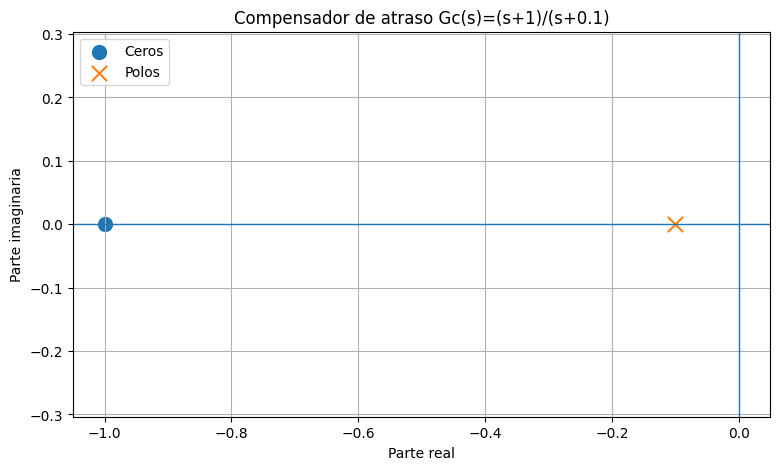

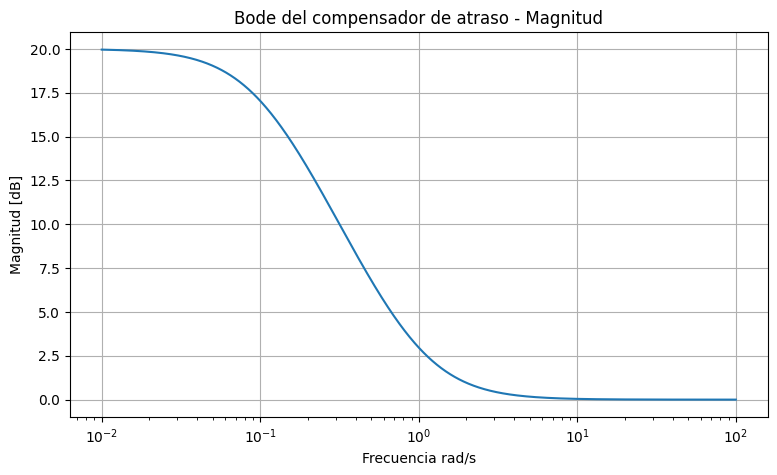

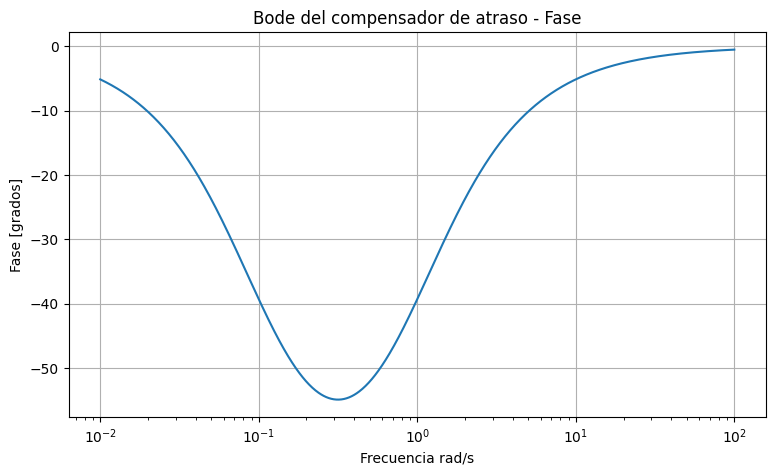

In [8]:
# Compensador de atraso
num_lag = [1, 1]
den_lag = [1, 0.1]

plot_pz(num_lag, den_lag, "Compensador de atraso Gc(s)=(s+1)/(s+0.1)")
bode_plot(num_lag, den_lag, "Bode del compensador de atraso")

## 10.3 Compensador adelanto-atraso

Combina ambos efectos:

$$
G_c(s)=K_c
\frac{(s+z_1)(s+z_2)}
{(s+p_1)(s+p_2)}
$$

Un par polo-cero se diseña como adelanto para mejorar transitorio.  
Otro par polo-cero se diseña como atraso para mejorar precisión estacionaria.

Efectos típicos:

- mejora respuesta transitoria,
- reduce error estacionario,
- permite balancear rapidez y precisión.

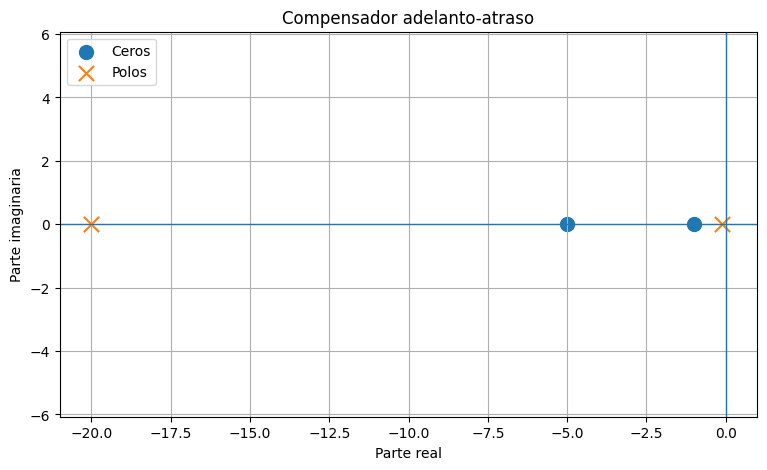

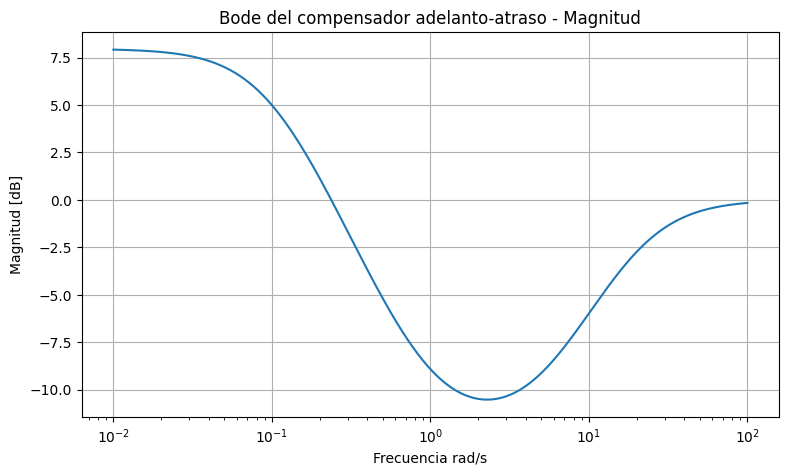

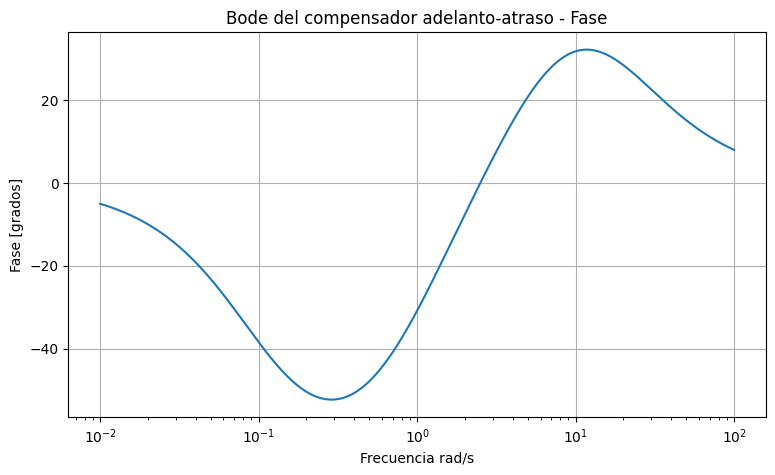

In [9]:
# Compensador adelanto-atraso ejemplo
num_leadlag = np.polymul([1, 5], [1, 1])       # (s+5)(s+1)
den_leadlag = np.polymul([1, 20], [1, 0.1])    # (s+20)(s+0.1)

plot_pz(num_leadlag, den_leadlag, "Compensador adelanto-atraso")
bode_plot(num_leadlag, den_leadlag, "Bode del compensador adelanto-atraso")

# 11. Diseño práctico sobre una planta de ejemplo

Tomemos nuevamente:

$$
G_p(s)=\frac{1}{s(s+2)}
$$

Compararemos cuatro casos en lazo cerrado:

1. planta con ganancia simple,
2. planta con compensador de adelanto,
3. planta con compensador de atraso,
4. planta con compensador adelanto-atraso.

Para que la comparación sea visualmente útil, ajustaremos ganancias de manera simple.  
No se busca aquí un diseño óptimo formal, sino una comprensión comparativa.

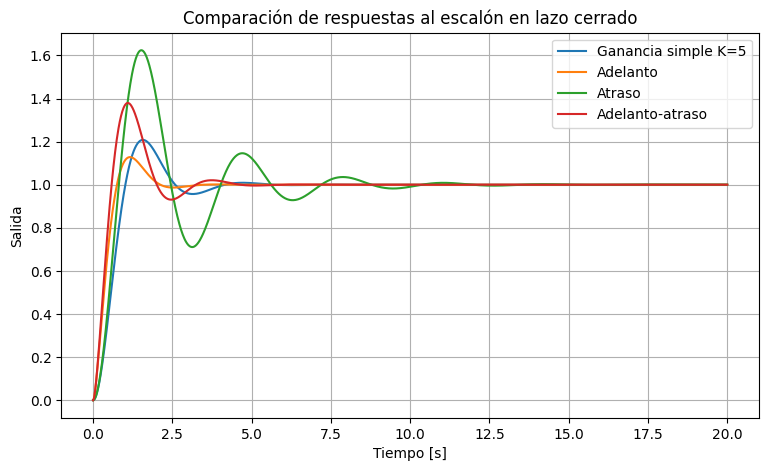

In [10]:
def series_tf(num1, den1, num2, den2):
    return np.polymul(num1, num2), np.polymul(den1, den2)

def step_closed_loop_from_open_loop(num_ol, den_ol, t):
    num_cl, den_cl = closed_loop_tf(num_ol, den_ol)
    sys = signal.TransferFunction(num_cl, den_cl)
    tout, y = signal.step(sys, T=t)
    return tout, y, num_cl, den_cl

t = np.linspace(0, 20, 1500)

cases = {}

# Caso base con K
K_base = 5
cases["Ganancia simple K=5"] = ([K_base], [1, 2, 0])

# Adelanto con ganancia
K_lead = 30
num_c_lead = np.array(num_lead) * K_lead
den_c_lead = den_lead
cases["Adelanto"] = series_tf(num_c_lead, den_c_lead, num_p, den_p)

# Atraso con ganancia
K_lag = 5
num_c_lag = np.array(num_lag) * K_lag
den_c_lag = den_lag
cases["Atraso"] = series_tf(num_c_lag, den_c_lag, num_p, den_p)

# Adelanto-atraso con ganancia
K_ll = 30
num_c_ll = np.array(num_leadlag) * K_ll
den_c_ll = den_leadlag
cases["Adelanto-atraso"] = series_tf(num_c_ll, den_c_ll, num_p, den_p)

plt.figure()
info = {}
for name, (num_ol, den_ol) in cases.items():
    tout, y, num_cl, den_cl = step_closed_loop_from_open_loop(num_ol, den_ol, t)
    plt.plot(tout, y, label=name)
    info[name] = (num_cl, den_cl)

plt.title("Comparación de respuestas al escalón en lazo cerrado")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.legend()
plt.show()

## Lectura cualitativa de la gráfica

La comparación permite observar:

- la ganancia simple modifica la rapidez pero puede comprometer el amortiguamiento;
- el adelanto tiende a mejorar el transitorio;
- el atraso mejora la precisión estacionaria, pero suele introducir lentitud;
- el adelanto-atraso permite combinar ambos criterios.

En un diseño real se utilizarían especificaciones como:

$$
M_p \leq M_{p,\text{max}}
$$

$$
t_s \leq t_{s,\text{max}}
$$

$$
e_{ss} \leq e_{ss,\text{max}}
$$

$$
PM \geq PM_{\text{mínimo}}
$$

donde:

- $M_p$: sobrepico,
- $t_s$: tiempo de establecimiento,
- $e_{ss}$: error estacionario,
- $PM$: margen de fase.

In [11]:
# Función auxiliar para estimar métricas de respuesta al escalón
def step_metrics(t, y, y_final=None, tol=0.02):
    if y_final is None:
        y_final = y[-1]
    peak = np.max(y)
    overshoot = 100 * (peak - y_final) / y_final if y_final != 0 else np.nan

    # Tiempo de subida 10%-90%
    try:
        t10 = t[np.where(y >= 0.1*y_final)[0][0]]
        t90 = t[np.where(y >= 0.9*y_final)[0][0]]
        rise_time = t90 - t10
    except Exception:
        rise_time = np.nan

    # Tiempo de establecimiento 2%
    band_low = y_final * (1 - tol)
    band_high = y_final * (1 + tol)
    settling_time = np.nan
    for i in range(len(y)):
        if np.all((y[i:] >= band_low) & (y[i:] <= band_high)):
            settling_time = t[i]
            break

    return {
        "valor_final": y_final,
        "sobrepico_%": overshoot,
        "tiempo_subida_10_90": rise_time,
        "tiempo_establecimiento_2%": settling_time
    }

for name, (num_ol, den_ol) in cases.items():
    tout, y, _, _ = step_closed_loop_from_open_loop(num_ol, den_ol, t)
    print(f"\n{name}")
    for k, v in step_metrics(tout, y).items():
        print(f"  {k}: {v:.4f}")


Ganancia simple K=5
  valor_final: 1.0000
  sobrepico_%: 20.7873
  tiempo_subida_10_90: 0.6805
  tiempo_establecimiento_2%: 3.7358

Adelanto
  valor_final: 1.0000
  sobrepico_%: 12.8029
  tiempo_subida_10_90: 0.5337
  tiempo_establecimiento_2%: 1.9213

Atraso
  valor_final: 1.0000
  sobrepico_%: 62.3948
  tiempo_subida_10_90: 0.5470
  tiempo_establecimiento_2%: 8.4056

Adelanto-atraso
  valor_final: 1.0000
  sobrepico_%: 37.9246
  tiempo_subida_10_90: 0.4270
  tiempo_establecimiento_2%: 3.8559


# 12. Teoremas de valor inicial, final y medio

Los teoremas de valor permiten conectar directamente la expresión en Laplace con información temporal clave.

## Teorema del valor inicial

$$
y(0^+)=\lim_{s\to\infty}sY(s)
$$

Este teorema permite conocer el comportamiento inicial sin hacer antitransformada completa.

Interpretación:

- $s\to\infty$ representa componentes rápidas;
- el inicio de la respuesta está dominado por alta frecuencia;
- sirve para detectar saltos o discontinuidades iniciales.

## Teorema del valor final

$$
y(\infty)=\lim_{s\to0}sY(s)
$$

Este teorema permite conocer el estado estacionario.

Interpretación:

- $s\to0$ representa comportamiento lento;
- permite calcular valor final y error estacionario;
- requiere estabilidad adecuada del sistema.

## Condición importante

El teorema del valor final solo es válido si todos los polos de $sY(s)$ están en el semiplano izquierdo, excepto como máximo un polo simple en el origen.

## Ejemplo: valor final de un sistema de primer orden

Sea:

$$
G(s)=\frac{1}{s+1}
$$

con entrada escalón:

$$
X(s)=\frac{1}{s}
$$

Entonces:

$$
Y(s)=G(s)X(s)=\frac{1}{s(s+1)}
$$

Valor final:

$$
y(\infty)=\lim_{s\to0}sY(s)
$$

$$
y(\infty)=\lim_{s\to0}\frac{1}{s+1}=1
$$

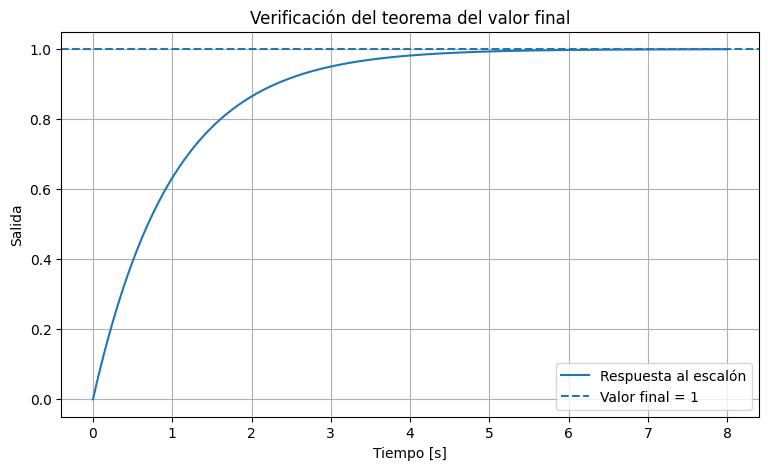

In [12]:
# Verificación numérica del valor final
sys_first = signal.TransferFunction([1], [1, 1])
t1 = np.linspace(0, 8, 500)
t1, y1 = signal.step(sys_first, T=t1)

plt.figure()
plt.plot(t1, y1, label="Respuesta al escalón")
plt.axhline(1, linestyle="--", label="Valor final = 1")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.title("Verificación del teorema del valor final")
plt.legend()
plt.show()

## Teorema del valor medio

En señales periódicas o en análisis de contenido DC, el valor medio suele relacionarse con la componente de frecuencia cero.

Para una señal periódica $x(t)$ de período $T$:

$$
\overline{x}=\frac{1}{T}\int_0^T x(t)\,dt
$$

En términos de Fourier, el valor medio es la componente DC.

En sistemas lineales, la ganancia DC:

$$
G(0)
$$

indica cómo el sistema amplifica o atenúa el valor medio de una señal suficientemente lenta o constante.

Si la entrada posee valor medio $\overline{x}$, y el sistema es estable, entonces la salida estacionaria tendrá aproximadamente:

$$
\overline{y}=G(0)\overline{x}
$$

Esta idea conecta control, filtros, procesamiento de señales y análisis de régimen permanente.

In [13]:
# Valor medio de una señal periódica y efecto de una ganancia DC
T = 2*np.pi
t2 = np.linspace(0, 4*T, 2000)

x2 = 2 + np.sin(t2) + 0.3*np.sin(5*t2)
mean_x = np.trapz(x2[:500], t2[:500]) / (t2[499] - t2[0])

plt.figure()
plt.plot(t2, x2, label="x(t)")
plt.axhline(mean_x, linestyle="--", label=f"Valor medio ≈ {mean_x:.2f}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Valor medio como componente DC")
plt.legend()
plt.show()

AttributeError: module 'numpy' has no attribute 'trapz'

# 13. Comparación de Bode del sistema abierto compensado

Ahora comparemos la respuesta en frecuencia de:

$$
G_{OL}(s)=G_c(s)G_p(s)
$$

para distintos compensadores.

Esto permite observar cómo el compensador modifica:

- ganancia de baja frecuencia,
- pendiente de magnitud,
- fase,
- posible margen de fase,
- sensibilidad a ruido.

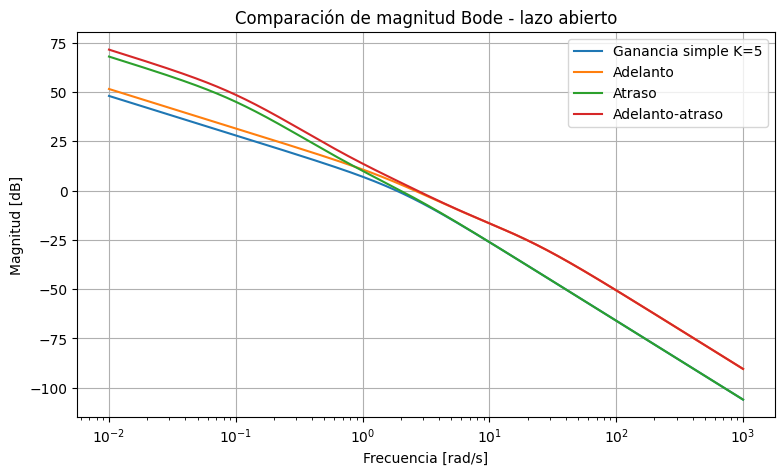

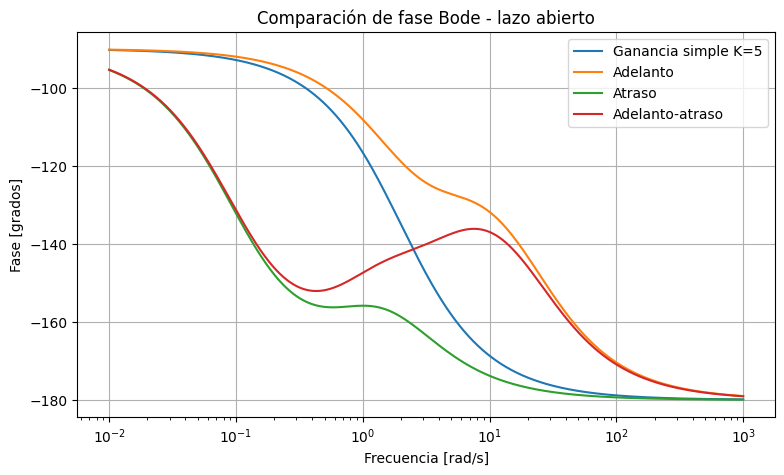

In [14]:
plt.figure()
for name, (num_ol, den_ol) in cases.items():
    w, mag, phase = signal.bode((num_ol, den_ol), w=np.logspace(-2, 3, 1200))
    plt.semilogx(w, mag, label=name)
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Magnitud [dB]")
plt.title("Comparación de magnitud Bode - lazo abierto")
plt.legend()
plt.show()

plt.figure()
for name, (num_ol, den_ol) in cases.items():
    w, mag, phase = signal.bode((num_ol, den_ol), w=np.logspace(-2, 3, 1200))
    plt.semilogx(w, phase, label=name)
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Fase [grados]")
plt.title("Comparación de fase Bode - lazo abierto")
plt.legend()
plt.show()

# 14. Interpretación física de los compensadores

## Adelanto

Un compensador de adelanto agrega fase positiva.  
Su efecto puede interpretarse como una acción parcialmente anticipativa.

Tiende a:

- acelerar la respuesta,
- mejorar margen de fase,
- mover polos dominantes hacia regiones más favorables,
- aumentar ancho de banda.

Pero puede:

- aumentar sensibilidad al ruido,
- exigir mayor esfuerzo de control.

## Atraso

Un compensador de atraso aumenta la ganancia en baja frecuencia.  
Su efecto puede interpretarse como una memoria lenta que mejora la precisión.

Tiende a:

- reducir error estacionario,
- mejorar seguimiento de referencias constantes,
- mejorar rechazo de perturbaciones lentas.

Pero puede:

- ralentizar la respuesta,
- reducir margen de fase si se ubica mal.

## Adelanto-atraso

Busca combinar:

$$
\text{mejor transitorio} + \text{mejor régimen permanente}
$$

Es uno de los recursos clásicos más potentes antes de entrar en control moderno o diseño óptimo.

# 15. Conclusiones generales

La función de transferencia no es solo un cociente entre salida y entrada:

$$
G(s)=\frac{Y(s)}{X(s)}
$$

Es la representación algebraica de un operador dinámico.

En el tiempo:

$$
y(t)=g(t)*x(t)
$$

En Laplace:

$$
Y(s)=G(s)X(s)
$$

Por eso el álgebra de bloques funciona: porque la transformada de Laplace convierte convolución en multiplicación.

Los compensadores funcionan porque agregan polos y ceros que modifican:

- la respuesta temporal,
- la respuesta en frecuencia,
- la ecuación característica,
- los polos del sistema cerrado,
- el error estacionario,
- la estabilidad relativa.

En una frase:

> Control clásico es ingeniería espectral de sistemas dinámicos lineales.

Diseñar compensadores es modificar cuidadosamente la memoria dinámica de la planta para obtener el comportamiento físico deseado.

# 16. Ejercicios propuestos

## Ejercicio 1

Para la planta:

$$
G_p(s)=\frac{10}{s(s+4)}
$$

1. Obtener la función de transferencia de lazo cerrado con realimentación unitaria.
2. Graficar la respuesta al escalón.
3. Estimar sobrepico y tiempo de establecimiento.

## Ejercicio 2

Diseñar un compensador de adelanto:

$$
G_c(s)=K\frac{s+z}{s+p}
$$

con:

$$
z<p
$$

Probar distintos valores y analizar cómo cambia la respuesta.

## Ejercicio 3

Diseñar un compensador de atraso para mejorar el error estacionario de una planta tipo 0.

## Ejercicio 4

Comparar Bode antes y después de compensar.

## Ejercicio 5

Verificar numéricamente el teorema del valor final en un sistema estable y en uno inestable. Explicar por qué falla en el segundo caso.

# 17. Código libre para experimentación

La siguiente celda queda preparada para que modifiques plantas, compensadores y ganancias.

In [ ]:
# Zona de experimentación

# Definir planta
num_p_exp = [1]
den_p_exp = [1, 3, 2]   # ejemplo: (s+1)(s+2)

# Definir compensador
K_exp = 1
num_c_exp = np.array([1, 4]) * K_exp
den_c_exp = [1, 12]

# Sistema abierto compensado
num_ol_exp, den_ol_exp = series_tf(num_c_exp, den_c_exp, num_p_exp, den_p_exp)

# Sistema cerrado
t_exp = np.linspace(0, 15, 1000)
tout, y, num_cl_exp, den_cl_exp = step_closed_loop_from_open_loop(num_ol_exp, den_ol_exp, t_exp)

plot_pz(num_ol_exp, den_ol_exp, "Polos y ceros del lazo abierto compensado")

plt.figure()
plt.plot(tout, y)
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.title("Respuesta al escalón del sistema cerrado experimental")
plt.show()

bode_plot(num_ol_exp, den_ol_exp, "Bode del lazo abierto experimental")